Import `podio` reader to read root file.

In [2]:
from podio.root_io import Reader

Module libc not found.


Welcome to JupyROOT 6.28/06


/opt/podio/v00-17-02/python/podio/EventStore.py:4: FutureWarning: The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.
  warnings.warn("The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.",


Open root file generated by simple_digi. 
Replace the path with personal data. 

In [3]:
reader = Reader( 'data/compton_digi.root')

# Process One Event
Take the 0th event for demonstration.

In [4]:
event_to_proc = 0

events = reader.get( "events" )
event  = events[event_to_proc]
hits   = event.get( "TpcHits" )

See the number of hits. 

In [5]:
print(f"Number of hits = {len(hits)}")

Number of hits = 80


Convert raw hits collection to numpy matrix.

In [6]:
import numpy as np
from RecoUtils import decodeRawHits

dhits =  decodeRawHits(hits)

Info in <TGeoManager>: Changing system of units to Geant4 units (mm, ns, MeV).


Rebuild 3D hits from 2d hits.

In [7]:
from Hit3DBuilder import build3d

search_band = 100
tor = 15

pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)

Convert 3D hit pairs to 3D matrix.

In [8]:
drift_velocity = 6
pair_mapper = np.frompyfunc(lambda pair: (pair.x(), pair.y(), pair.time() / 1000 * drift_velocity), 1, 3)

hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
print(hits_3d)

[[-36.33368060156493 145.4705503196778 4.630476013183594]
 [-39.55100161475006 140.55035103671977 8.749768798828125]
 [-41.622767467566966 137.37937989587775 10.060553833007813]
 [-43.46501956585408 134.5901729680145 11.889257080078126]
 [-47.40552526971827 130.4119642192465 14.701839843750001]
 [-49.469385072533456 128.5088981246082 16.565441894531247]
 [-50.39533095740117 127.48895789024371 16.933959228515626]
 [-52.331371488290074 126.56916840189999 17.868923583984376]
 [-53.43758100902707 125.5992021468999 19.37619873046875]
 [-55.491986889369414 120.49878894565819 21.4029755859375]
 [-57.49028463985172 120.49878894565819 21.48539208984375]
 [-58.511606991742724 116.53704553648872 24.013765869140624]
 [-61.48054567756154 113.50414501571929 25.76084619140625]]


A helper function to plot 3D scatter.

In [9]:
%matplotlib widget
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from RecoUtils import clusterCenter

def plot3d(hits_3d, color = "blue", labels = None, hide_distinct = False, ax = None):
    if ax is None:
        fig = plt.figure()
        ax = plt.axes(projection="3d")
    ax.set_xlabel('X', fontweight='bold')
    ax.set_ylabel('Y', fontweight='bold')
    ax.set_zlabel('Z', fontweight='bold')
    if labels is None:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], color=color)
    else:
        ax.scatter3D(hits_3d[:, 0], hits_3d[:, 1], hits_3d[:, 2], c=labels)
        centers = clusterCenter(hits_3d, labels)
        for c in centers:
            if hide_distinct and c[3] == -1:
                break
            ax.text(c[0], c[1], c[2], int(c[3]))

View rebuilt 3D points.

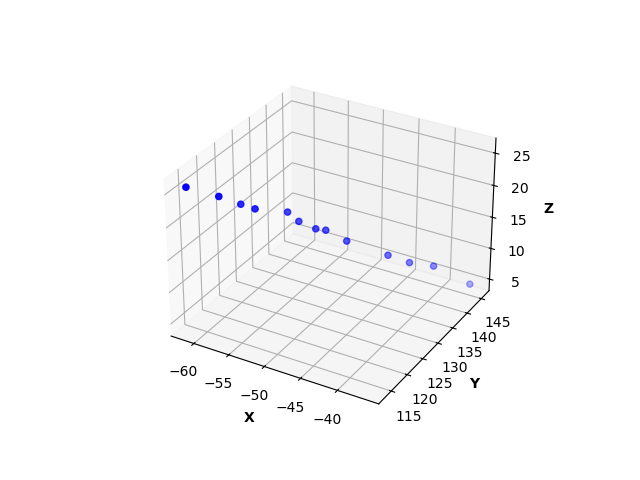

In [10]:
plot3d(hits_3d)
plt.show()

Cluster and view the result. 

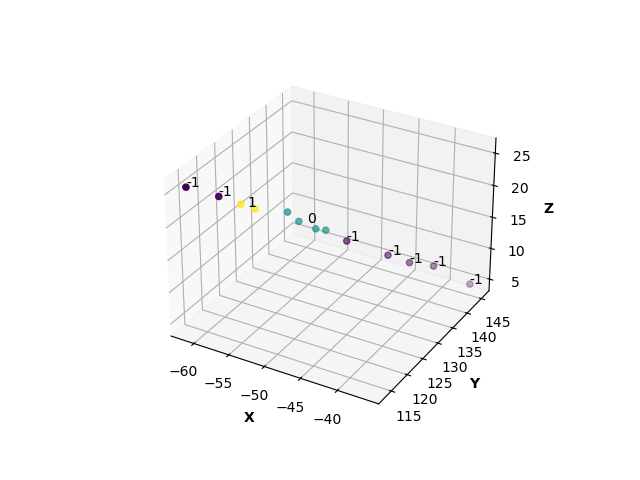

In [11]:
from sklearn.cluster import DBSCAN

clusters = DBSCAN(eps=3, min_samples=2).fit(hits_3d)
labels = clusters.labels_

plot3d(hits_3d, labels=labels)
plt.show()

# Some more events

ValueError: Found array with 0 sample(s) (shape=(0, 3)) while a minimum of 1 is required by DBSCAN.

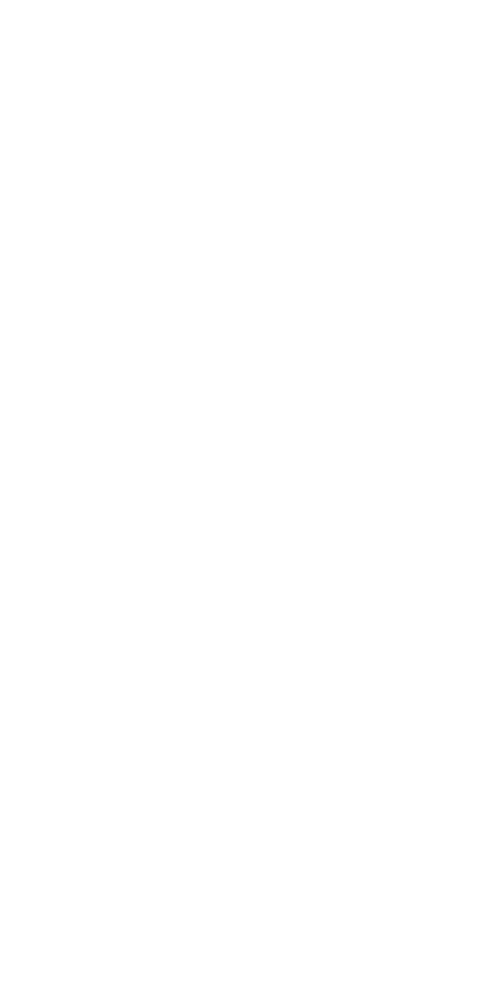

In [12]:
events_to_proc = range(1, 3)
n = len(events_to_proc)
fig = plt.figure(figsize=(5, 5 * n))
for i in range(n):
    event  = events[events_to_proc[i]]
    hits   = event.get( "TpcHits" )
    dhits =  decodeRawHits(hits)
    pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
    hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
    clusters = DBSCAN(eps=3, min_samples=2).fit(hits_3d)
    labels = clusters.labels_
    ax = fig.add_subplot(n, 1, 1 + i, projection="3d")
    plot3d(hits_3d, labels=labels, ax=ax)
plt.show()

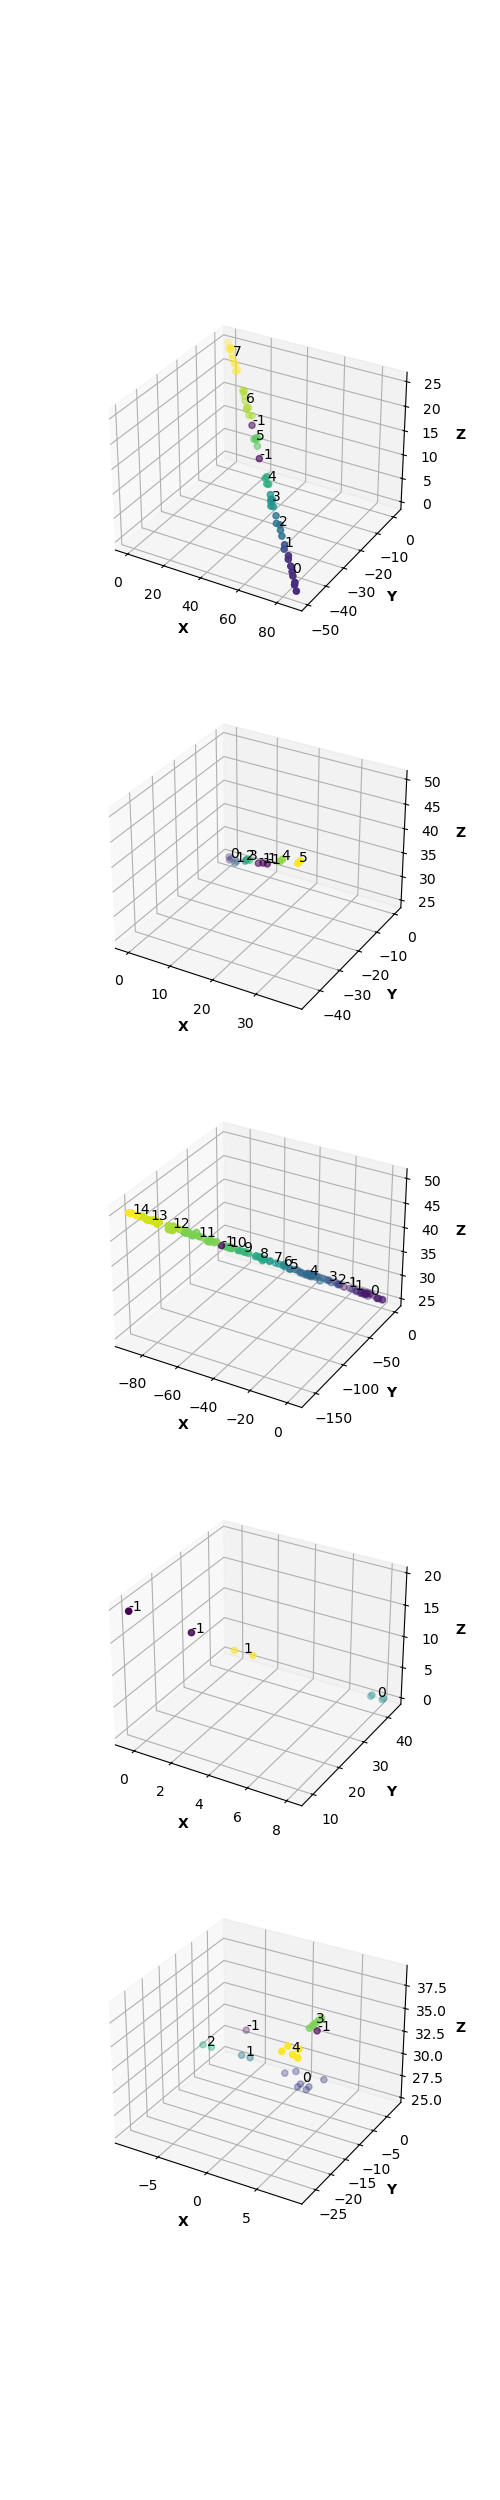

In [12]:
events_to_proc = range(10, 15)
n = len(events_to_proc)
fig = plt.figure(figsize=(5, 5 * n))
for i in range(n):
    event  = events[events_to_proc[i]]
    hits   = event.get( "TpcHits" )
    dhits =  decodeRawHits(hits)
    pairs = build3d(dhits.x_hits, dhits.y_hits, search_band, tor)
    hits_3d = np.stack(pair_mapper(np.array(pairs)), axis=1)
    clusters = DBSCAN(eps=3, min_samples=2).fit(hits_3d)
    labels = clusters.labels_
    ax = fig.add_subplot(n, 1, 1 + i, projection="3d")
    plot3d(hits_3d, labels=labels, ax=ax)
plt.show()